# Project Goal: 

**Background and Motivation:** The global bond market plays a critical role in financing development projects, with international institutions such as the International Bank for Reconstruction and Development (IBRD) issuing bonds across multiple currencies to fund initiatives worldwide. Bonds vary widely in their coupon rates, maturity periods, settlement timelines, and issuance volumes, reflecting both market demand and strategic funding considerations. Understanding these characteristics is essential for investors, policymakers, and financial analysts seeking to optimize portfolio allocation, manage currency exposure, and anticipate funding costs.

This project is motivated by the need to systematically explore patterns in IBRD’s bond issuance across different currencies. Key questions include:
How do maturity years and coupon rates vary by currency, and which currencies dominate long or short term funding?
What proportion of bonds mature within certain time horizons, and are there outliers that influence risk profiles?
How do settlement years and issuance volume interact with currency choice and bond terms?

By analyzing these patterns, the project aims to provide a comprehensive view of IBRD’s bond issuance strategies, highlighting currency-specific characteristics and offering insights for risk management, investment strategy, and financial planning. Ultimately, this analysis can help stakeholders understand both the temporal and financial dynamics of sovereign-backed bond issuance in a multi-currency context.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import math 

## 1) Loading Dataset

I will be using the Medical Cost Personal Datasets from Kaggle. It is retrieved from, https://www.kaggle.com/datasets/mirichoi0218/insurance/data

In [4]:
bonds = pd.read_csv("world_bank_ibrd_bonds_1947_present_02-12-2026.csv")

print('\nData Preview:')
display(bonds.head())
display(bonds.info())



Data Preview:


,Institution,Type,Maturity,Currency,Volume,Coupon,Settlement Date,Maturity Date,USD Equivalent,ISIN,Final Terms
0,IBRD,PV MTN Non-Core,2.08,CNH,568000000,0.01750,12/24/2025,01/24/2028,80632568.18,XS2982333713,https://thedocs.worldbank.org/en/doc/8aa84892c...
1,IBRD,Callable MTN Core,10.01,USD,50000000,0.04555,12/24/2025,12/24/2035,50000000.00,XS3259375999,NaN
2,IBRD,PV MTN Non-Core,2.00,UYU,400000000,0.07000,12/24/2025,12/24/2027,10178117.05,XS3259372970,https://thedocs.worldbank.org/en/doc/5725c7342...
3,IBRD,Callable MTN Core,10.01,USD,30000000,0.04540,12/23/2025,12/23/2035,30000000.00,XS3258459026,NaN
4,IBRD,Callable MTN Core,5.00,USD,25000000,0.03800,12/23/2025,12/23/2030,25000000.00,US45906M6N65,NaN


<class 'pandas.DataFrame'>
RangeIndex: 13247 entries, 0 to 13246
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Institution      13247 non-null  str    
 1   Type             10346 non-null  str    
 2   Maturity         12235 non-null  float64
 3   Currency         13247 non-null  str    
 4   Volume           13247 non-null  int64  
 5   Coupon           13134 non-null  float64
 6   Settlement Date  13247 non-null  str    
 7   Maturity Date    10130 non-null  str    
 8   USD Equivalent   12900 non-null  float64
 9   ISIN             9924 non-null   str    
 10  Final Terms      1565 non-null   str    
dtypes: float64(3), int64(1), str(7)
memory usage: 1.8 MB


None

## 2) Exploratory Data Analysis

In [5]:
print('\nInfo:')
pd.set_option('display.max_info_columns', 200)
print(bonds.info())
print('\nShape:')
print(bonds.shape)
bonds.describe(include='all')


Info:
<class 'pandas.DataFrame'>
RangeIndex: 13247 entries, 0 to 13246
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Institution      13247 non-null  str    
 1   Type             10346 non-null  str    
 2   Maturity         12235 non-null  float64
 3   Currency         13247 non-null  str    
 4   Volume           13247 non-null  int64  
 5   Coupon           13134 non-null  float64
 6   Settlement Date  13247 non-null  str    
 7   Maturity Date    10130 non-null  str    
 8   USD Equivalent   12900 non-null  float64
 9   ISIN             9924 non-null   str    
 10  Final Terms      1565 non-null   str    
dtypes: float64(3), int64(1), str(7)
memory usage: 1.8 MB
None

Shape:
(13247, 11)


,Institution,Type,Maturity,Currency,Volume,Coupon,Settlement Date,Maturity Date,USD Equivalent,ISIN,Final Terms
count,13247,10346,12235.000000,13247,1.324700e+04,13134.000000,13247,10130,1.290000e+04,9924,1565
unique,1,20,NaN,79,NaN,NaN,6018,5508,NaN,7933,1554
top,IBRD,Structure,NaN,USD,NaN,NaN,03/06/1985,09/15/1995,NaN,XS0490455069,https://thedocs.worldbank.org/en/doc/044a9f603...
freq,13247,2983,NaN,4786,NaN,NaN,60,26,NaN,18,2
mean,NaN,NaN,9.929149,NaN,6.418585e+09,0.048734,NaN,NaN,1.024911e+08,NaN,NaN
std,NaN,NaN,9.874302,NaN,5.218824e+10,0.201904,NaN,NaN,3.820179e+08,NaN,NaN
min,NaN,NaN,-87.000000,NaN,1.000000e+03,0.000000,NaN,NaN,1.000000e+03,NaN,NaN
25%,NaN,NaN,3.000000,NaN,2.000000e+07,0.000000,NaN,NaN,5.750000e+06,NaN,NaN
50%,NaN,NaN,5.000000,NaN,1.000000e+08,0.042000,NaN,NaN,2.000000e+07,NaN,NaN
75%,NaN,NaN,12.000000,NaN,5.000000e+08,0.075000,NaN,NaN,6.736250e+07,NaN,NaN


In [31]:
bonds['Settlement Date'] = pd.to_datetime(bonds['Settlement Date'], errors='coerce')
bonds_clean = bonds.dropna(subset=['USD Equivalent', 'Coupon', 'Settlement Date']).copy()
top_10_curr = bonds_clean['Currency'].value_counts().nlargest(10).index
bonds_clean = bonds_clean[bonds_clean['Currency'].isin(top_10_curr)]
bonds_clean['Settlement_Year'] = bonds_clean['Settlement Date'].dt.year
bonds_clean

,Institution,Type,Maturity,Currency,Volume,Coupon,Settlement Date,Maturity Date,USD Equivalent,ISIN,Final Terms,Settlement_Year
1,IBRD,Callable MTN Core,10.01,USD,50000000,0.04555,2025-12-24,12/24/2035,50000000.0,XS3259375999,NaN,2025
3,IBRD,Callable MTN Core,10.01,USD,30000000,0.04540,2025-12-23,12/23/2035,30000000.0,XS3258459026,NaN,2025
4,IBRD,Callable MTN Core,5.00,USD,25000000,0.03800,2025-12-23,12/23/2030,25000000.0,US45906M6N65,NaN,2025
5,IBRD,Callable MTN Core,10.01,USD,25000000,0.04550,2025-12-22,12/22/2035,25000000.0,XS3257721236,NaN,2025
7,IBRD,Callable MTN Core,10.01,USD,75000000,0.04550,2025-12-19,12/19/2035,75000000.0,XS3256253413,NaN,2025
...,...,...,...,...,...,...,...,...,...,...,...,...
13242,IBRD,NaN,10.00,USD,2000000,0.08800,1988-02-16,02/16/1998,2000000.0,NaN,NaN,1988
13243,IBRD,NaN,NaN,CHF,50000000,0.04000,1988-02-15,NaN,36300000.0,NaN,NaN,1988
13244,IBRD,NaN,10.00,USD,7000000,0.08900,1988-02-11,02/16/1998,7000000.0,NaN,NaN,1988
13245,IBRD,NaN,5.00,USD,1000000,0.08200,1988-02-10,02/10/1993,1000000.0,NaN,NaN,1988


In [19]:
currency_stats = bonds_clean.groupby('Currency').agg({
    'USD Equivalent': 'sum',
    'Coupon': 'mean'
}).rename(columns={'USD Equivalent': 'Total_USD_Volume', 'Coupon': 'Avg_Coupon'})

currency_stats

,Total_USD_Volume,Avg_Coupon
Currency,,
AUD,5.937763e+10,0.042752
BRL,9.921436e+09,0.110028
CHF,2.448558e+10,0.058761
DEM,3.707595e+10,0.071139
EUR,8.708404e+10,0.017910
INR,5.796200e+09,0.051431
JPY,8.514827e+10,0.008885
NZD,2.796570e+10,0.053634
USD,7.440017e+11,0.046939


## Breakdown

**Total_USD_Volume**: Total amount IBRD borrowed in that currency.  
**Avg_Coupon**: Average interest rate paid to investors in that currency.  

Each row shows how much IBRD borrowed in a market and how expensive it is to borrow.

### Biggest Markets
| Currency | Total_USD_Volume | Avg_Coupon |
|----------|-----------------|------------|
| USD      | 744B             | 4.7%       |
| EUR      | 87B              | 1.79%      |
| JPY      | 85B              | 0.89%      |
| AUD      | 59B              | 4.28%      |
| DEM      | 37B              | 7.11%      |

### Smallest Markets
| Currency | Total_USD_Volume | Avg_Coupon |
|----------|-----------------|------------|
| INR      | 6B               | 5.14%      |
| BRL      | 10B              | 11%        |
| ZAR      | 21B              | 8.39%      |
| CHF      | 24B              | 5.9%       |
| NZD      | 27B              | 5.36%      |

### Cheapest Fundings
| Currency | Total_USD_Volume | Avg_Coupon |
|----------|-----------------|------------|
| JPY      | 85B             | 0.89%      |
| EUR      | 87B             | 1.79%      |
| AUD      | 59B             | 4.28%      |

### Most Expensive Fundings
| Currency | Total_USD_Volume | Avg_Coupon |
|----------|-----------------|------------|
| BRL      | 9B              | 11.0%      |
| ZAR      | 20B             | 8.39%      |
| DEM      | 37B             | 7.11%      |

### Key Insights

- **USD** dominates massively and is the **main funding market**.  
- **EUR** has high volume and low cost, making it an **attractive market**.  
- **JPY** has high volume and very low cost, suggesting IBRD may use Japan’s **low interest environment** to reduce overall funding costs.  
- **BRL** has low volume and high cost, suggesting it is used **opportunistically** when strong investor demand exists.  

Overall, IBRD borrows heavily in **deep and stable markets** (USD, EUR) and accesses **higher-cost emerging markets selectively**.

In [67]:
bonds_clean['Type'] = bonds_clean['Type'].str.strip().str.title()

inst_stats = bonds_clean.groupby('Type').agg({
    'Maturity': ['mean'],
    'USD Equivalent': ['sum']
}).rename(columns={ 'Maturity': 'Average_Maturity (in Yrs)', 'USD Equivalent': 'Total_USD_Volume'})

inst_stats

,Average_Maturity (in Yrs),Total_USD_Volume
,mean,sum
Type,,
Blockchain,2.000000,8.021000e+07
Callable Mtn Core,19.438783,1.076618e+11
Callable Mtn Non-Core,5.666667,9.554500e+07
Global,10.000000,1.500000e+09
Green,6.829913,1.802403e+10
Other (Cat),4.000000,1.245000e+09
Other (Outcome Bond),9.000000,2.250000e+08
Other Structures,4.330000,8.643483e+08


## Breakdown

### Largest Funding Types
| Type              | Average Maturity (Y) | Total USD Volume |
|------------------|--------------------|----------------|
| Pv Bm             | 7.9                | 444B           |
| Structure         | 8                  | 214B           |
| Callable Mtn Core | 19                 | 107B           |
| Pv Mtn Core       | 15                 | 82B            |
| Us$ Callable Bm   | 9.4                | 47B            |

### Smallest Funding Types
| Type                  | Average Maturity (Y) | Total USD Volume |
|-----------------------|--------------------|----------------|
| Blockchain            | 2                  | 0.08B          |
| Callable Mtn Non-Core | 5.7                | 0.1B           |
| Other (Outcome Bond)  | 9                  | 0.2B           |
| Other Structures      | 4.3                | 0.8B           |
| Other (Cat)           | 4                  | 1B             |

### Longest Maturity
| Type                  | Average Maturity (Y) | Total USD Volume |
|-----------------------|--------------------|----------------|
| Callable Mtn Core     | 19                 | 107B           |
| Pv Mtn Core           | 15                 | 82B            |
| Global                | 10                 | 1.5B           |
| Us$ Callable Bm       | 9.4                | 47B            |
| Other (Outcome Bond)  | 9                  | 0.2B           |

### Shortest Maturity
| Type                  | Average Maturity (Y) | Total USD Volume |
|-----------------------|--------------------|----------------|
| Blockchain            | 2                  | 0.08B          |
| Other (Cat)           | 4                  | 1B             |
| Putable               | 4.2                | 13B            |
| Other Structures      | 4.3                | 0.8B           |
| Us$ Callable Benchmark| 4.5                | 7B             |

### Key Insights

- **Pv Bm** and **Structure** are the core funding instruments, with high issuance volumes (over 650B combined) and medium-term maturities (~8 years).  
- **Callable Mtn Core** and **Pv Mtn Core** have long maturities (15–19 years), indicating that IBRD secures long-duration funding to match its long-term development lending.  
- Smaller-volume instruments such as **Blockchain**, **Cat Bonds**, and **Outcome Bonds** are innovative, targeted, or specialized funding tools rather than core funding sources.  
- IBRD’s funding strategy is heavily concentrated in **plain vanilla benchmark** and **structured bonds**, forming the backbone of issuance, while longer-term funding relies on **callable MTN programs**.

## 3) Visualisations

In [29]:
issuance_pivot = bonds_clean.pivot_table(
    index='Settlement_Year', 
    columns='Currency', 
    values='USD Equivalent', 
    aggfunc='sum'
)

issuance_pivot

Currency,AUD,BRL,CHF,DEM,EUR,INR,JPY,NZD,USD,ZAR
Settlement_Year,,,,,,,,,,
1947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.150000e+08,NaN
1948,NaN,NaN,3.955788e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1950,NaN,NaN,6.317630e+05,NaN,NaN,NaN,NaN,NaN,1.000000e+08,NaN
1951,NaN,NaN,1.163467e+07,NaN,NaN,NaN,NaN,NaN,1.500000e+08,NaN
1952,NaN,NaN,1.163467e+07,NaN,NaN,NaN,NaN,NaN,1.100000e+08,NaN
...,...,...,...,...,...,...,...,...,...,...
2021,2.148512e+09,3.111914e+08,NaN,NaN,6.907653e+09,7.820514e+07,NaN,1.943202e+09,3.179700e+10,2.465881e+08
2022,9.147716e+08,1.916703e+08,1.008776e+07,NaN,1.906423e+09,7.748356e+07,NaN,4.979500e+08,1.738196e+10,1.321395e+08
2023,2.397735e+09,1.961899e+08,NaN,NaN,9.389953e+09,1.030195e+09,NaN,1.072305e+09,2.991098e+10,5.043732e+09


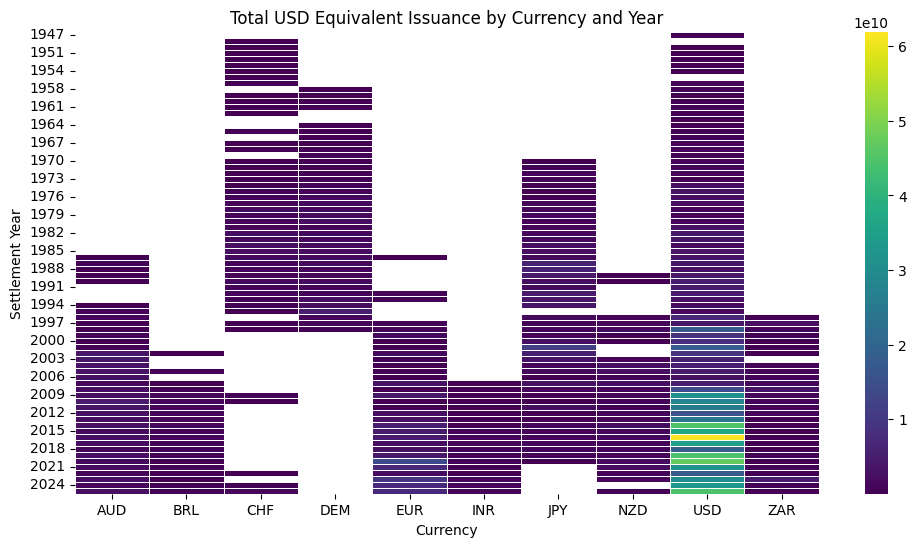

In [58]:
plt.figure(figsize=(12,6))
sns.heatmap(issuance_pivot, cmap="viridis", linewidths=0.5)

plt.title("Total USD Equivalent Issuance by Currency and Year")
plt.xlabel("Currency")
plt.ylabel("Settlement Year")
plt.show()

The heatmap, using a viridis color scale, highlights the dominance of USD-denominated issuance while revealing temporal shifts in issuance volumes across other currencies. Darker tones indicate lower issuance volumes, while brighter tones represent peak issuance periods.

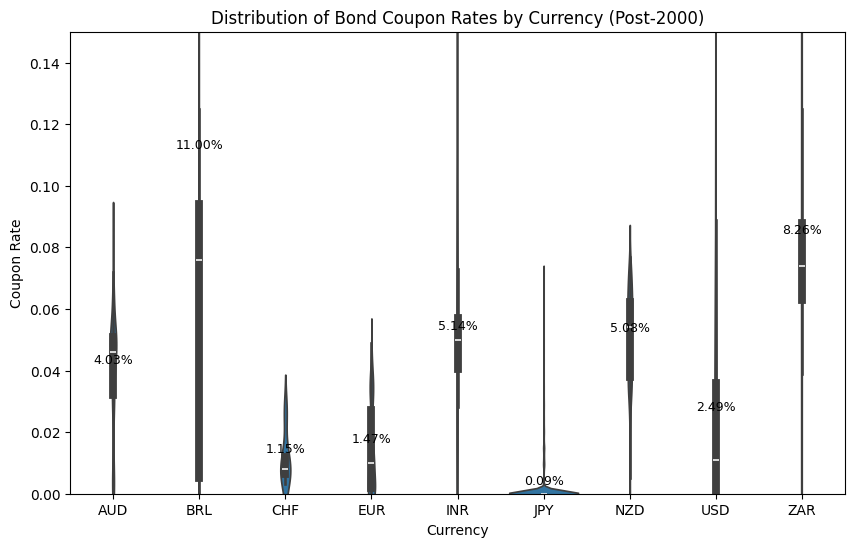

In [54]:
bonds_recent = bonds_clean[bonds_clean["Settlement Date"].dt.year >= 2000]
plt.figure(figsize=(10,6))
sns.violinplot(data=bonds_recent, x="Currency", y="Coupon", inner="box", order=order)
plt.ylim(0, 0.15)

means = bonds_recent.groupby("Currency")["Coupon"].mean()
for i, currency in enumerate(means.index):
    plt.text(i, means[currency] + 0.002,
             f"{means[currency]:.2%}",
             ha='center',
             fontsize=9,
             color='black')
    
plt.title("Distribution of Bond Coupon Rates by Currency (Post-2000)")
plt.xlabel("Currency")
plt.ylabel("Coupon Rate")

plt.show()

Highest Coupon Rate:
BRL (~11.00%) has the highest average coupon rate.
ZAR (~8.26%) also shows relatively high coupons.
INR (~5.14%) and NZD (~5.08%) follow next.
BRL exhibits the tallest violin, indicating the widest range and greatest dispersion of coupon rates among all currencies. This reflects higher variability in interest rate conditions and greater risk premiums associated with BRL bond issuances. 

Mid Range Coupon Rate:
AUD (~4.03%)
USD (~2.49%)
These currencies show moderate coupon levels with noticeable spread, indicating variation over time depending on market conditions.

Lowest Coupon Rate:
EUR (~1.47%)
CHF (~1.15%)
JPY (~0.09%) 
These currencies reflect low interest rate environments in the post-2000 period. In particular, JPY shows an extremely low average coupon rate, consistent with JPY's low or near zero interest rate policy 

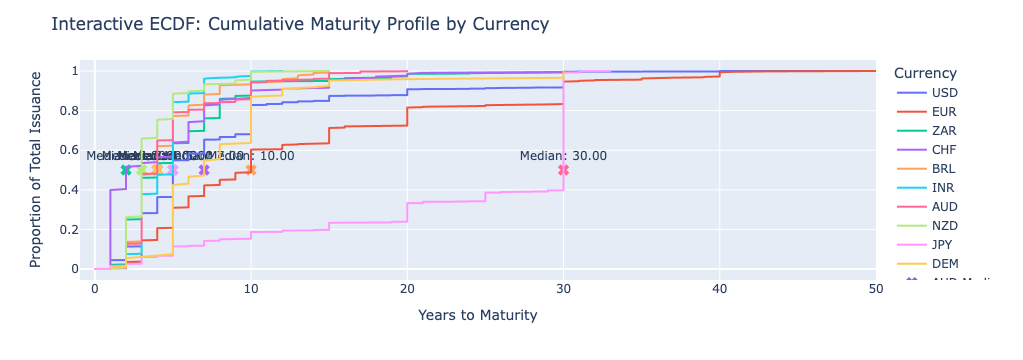

In [66]:
def compute_ecdf(df, value_col):
    x = np.sort(df[value_col])
    y = np.arange(1, len(x)+1) / len(x)
    return pd.DataFrame({value_col: x, 'ECDF': y})

ecdf_data = pd.concat([
    compute_ecdf(bonds_clean[bonds_clean['Currency'] == cur], 'Maturity').assign(Currency=cur)
    for cur in bonds_clean['Currency'].unique()
])

medians = bonds_clean.groupby('Currency')['Maturity'].median().reset_index()

fig = px.line(
    ecdf_data, 
    x='Maturity', 
    y='ECDF', 
    color='Currency',
    labels={'ECDF': 'Proportion of Total Issuance', 'Maturity': 'Years to Maturity'},
    hover_data={'Maturity': ':.2f', 'ECDF': ':.2f'}
)

for i, row in medians.iterrows():
    fig.add_scatter(
        x=[row['Maturity']], 
        y=[0.5], 
        mode='markers+text',
        marker=dict(size=10, symbol='x'),
        name=f"{row['Currency']} Median",
        text=[f"Median: {row['Maturity']:.2f}"], 
        textposition='top center',
        hoverinfo='text'
    )

fig.update_layout(
    title='Interactive ECDF: Cumulative Maturity Profile by Currency',
    xaxis_title='Years to Maturity',
    yaxis_title='Proportion of Total Issuance',
    hovermode='closest'
)

fig.show()

The cumulative maturity profile reveals a wide variation across currencies. JPY stands out with the longest median maturity, where 50% of JPY bonds mature in 30 years, making it a clear outlier. At the other extreme, bonds denominated in CHF, NZD, and BRL have the shortest median maturities, at 2, 3, and 4 years, respectively. Overall, 9 out of 10 currencies have the majority of their bond issuance maturing within 10 years, highlighting that long-dated bonds are generally rare, with JPY being the notable exception.